<a href="https://colab.research.google.com/github/VikiTarasova/Analysis_Cafe_Sales/blob/main/11_06_26_cafe_eda_workbook_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Робочий зошит: Data Cleaning & EDA
## Датасет: Cafe Sales — Dirty Data for Cleaning Training

> **Ваше завдання:** самостійно заповнити всі клітинки з `# ВАШ КОД ТУТ`.
> Підказки є у кожному розділі — але спробуйте спочатку без них!


---
### Структура проєкту
- **Частина 1** — Первинна інспекція (Tasks 1.1–1.3)
- **Частина 2** — Очищення даних (Tasks 2.1–2.4)
- **Частина 3** — EDA та візуалізація (Tasks 3.1–3.5)
- **Частина 4** — Висновки

---

## ⚙️ Підготовка

Завантажте датасет: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Вкажіть шлях до файлу у змінній `FILE_IN` нижче.
Можливі варіанти:
- **Локально:** `FILE_IN = 'data/dirty_cafe_sales.csv'`
- **GitHub Raw URL:** вкажіть посилання на raw-файл
- **Google Colab + Drive:** змонтуйте диск і вкажіть шлях

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# ── Вкажіть шлях до вхідного файлу ──────────────────────────
# FILE_IN = 'data/dirty_cafe_sales.csv'   # локальний варіант
FILE_IN = 'https://raw.githubusercontent.com/VikiTarasova/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

# ── Вкажіть шлях для збереження чистого файлу ───────────────
# FILE_OUT = 'data/cafe_sales_clean.csv'  # локальний варіант
FILE_OUT = 'https://raw.githubusercontent.com/VikiTarasova/Analysis_Cafe_Sales/refs/heads/main/data/cafe_sales_clean.csv'

print('✓ Готово. Починаємо!')

✓ Готово. Починаємо!


---
# ЧАСТИНА 1 — Первинна інспекція

---

## Task 1.1 — Завантаження та перший огляд

**Що потрібно зробити:**
1. Прочитати CSV файл у датафрейм `df`
2. Зберегти оригінал у `df_original` (на випадок якщо щось піде не так)
3. Вивести перші 10 рядків
4. Викликати `.info()` і `.describe(include='all')`

**Зверніть увагу:** які колонки мають тип `object` замість числових? Чому?

In [2]:
# Завантаження датасету
df_original = pd.read_csv(FILE_IN) # ВАШ КОД ТУТ

df = df_original.copy() # ВАШ КОД ТУТ  (копія оригіналу)

print(f'Розмір: {df.shape[0]} рядків × {df.shape[1]} стовпців')  # замініть ???

# Перші 10 рядків
print(df.head(10))

# ВАШ КОД ТУТ

Розмір: 10000 рядків × 8 стовпців
  Transaction ID      Item Quantity Price Per Unit Total Spent  \
0    TXN_1961373    Coffee        2            2.0         4.0   
1    TXN_4977031      Cake        4            3.0        12.0   
2    TXN_4271903    Cookie        4            1.0       ERROR   
3    TXN_7034554     Salad        2            5.0        10.0   
4    TXN_3160411    Coffee        2            2.0         4.0   
5    TXN_2602893  Smoothie        5            4.0        20.0   
6    TXN_4433211   UNKNOWN        3            3.0         9.0   
7    TXN_6699534  Sandwich        4            4.0        16.0   
8    TXN_4717867       NaN        5            3.0        15.0   
9    TXN_2064365  Sandwich        5            4.0        20.0   

   Payment Method  Location Transaction Date  
0     Credit Card  Takeaway       2023-09-08  
1            Cash  In-store       2023-05-16  
2     Credit Card  In-store       2023-07-19  
3         UNKNOWN   UNKNOWN       2023-04-27  
4  D

In [3]:
# Загальна інформація про датафрейм
df.info() # ВАШ КОД ТУТ

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [4]:
# Описова статистика (для числових І текстових колонок)
# Підказка: є параметр include='all'
df.describe(include='all') # ВАШ КОД ТУТ

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### ✏️ Спостереження після Task 1.1
*(Запишіть тут що ви помітили — підозрілі значення, неправильні типи, тощо)*

- ### Мої спостереження:

* Усі 8 колонок мають тип `object`, хоча **Quantity**, **Price Per Unit**, **Total Spent** мають бути числовими. Причина — наявність `ERROR`, `UNKNOWN` та `NaN`.  
* **Transaction Date** має тип `object`, потрібно перетворити у `datetime`.  
* Є пропуски (`ERROR`, `UNKNOWN`), які pandas не визначає як пропуски.  
* Найбільше пропусків у **Payment Method** (25%) та **Location** (33%).  
* У `describe()` видно, що `UNKNOWN` зустрічається навіть у **Transaction   Date**.
* **Transaction ID** має 10000 унікальних значень — дублікатів за ID немає, але повні дублікати потрібно перевірити.  
* Перед аналізом дані потрібно очистити та привести типи колонок до правильного формату.  



## Task 1.2 — Дублікати

**Що потрібно зробити:**
1. Порахувати кількість повних дублікатів
2. Видалити дублікати, зберігши перший зустрічний
3. Вивести кількість рядків до і після

**Підказка:** `df.duplicated()`, `df.drop_duplicates(keep=...)`

In [5]:
# Знайти дублікати
n_dupes = df.duplicated().sum()
print(f'Знайдено дублікатів: {n_dupes}')
print(f'Рядків до видалення: {len(df)}')

# Видалити дублікати
df = df.drop_duplicates(keep='first') # ВАШ КОД ТУТ

print(f'Рядків після видалення: {len(df)}')

Знайдено дублікатів: 0
Рядків до видалення: 10000
Рядків після видалення: 10000


## Task 1.3 — Аналіз пропущених значень

**Що потрібно зробити:**
1. Замінити значення `'ERROR'`, `'UNKNOWN'`, `''`, `' '` на `np.nan`
2. Порахувати пропуски по кожній колонці (кількість і %)
3. Порахувати загальний % пропусків
4. Побудувати **два** графіки: heatmap і bar chart

**Підказка:** `df.replace(список, np.nan)`, `df.isnull().sum()`

In [6]:
# Крок 1: замінити 'брудні' значення на NaN
df = df.replace(['ERROR', 'UNKNOWN', '', ' '], np.nan) # ВАШ КОД ТУТ

# Крок 2: порахувати пропуски
missing_count = df.isnull().sum()
missing_pct   =  (missing_count / len(df)) * 100   # (у відсотках від загальної кількості рядків)

missing_df = pd.DataFrame({'Пропусків': missing_count, '%': missing_pct})

# Показати тільки колонки де є пропуски
print(missing_df[missing_df['Пропусків'] > 0])

# Крок 3: загальний % пропусків
total_pct = (df.isnull().sum().sum() / df.size) * 100

print(f'\nЗагальний % пропусків: {total_pct:.2f}%')

                  Пропусків      %
Item                    969   9.69
Quantity                479   4.79
Price Per Unit          533   5.33
Total Spent             502   5.02
Payment Method         3178  31.78
Location               3961  39.61
Transaction Date        460   4.60

Загальний % пропусків: 12.60%


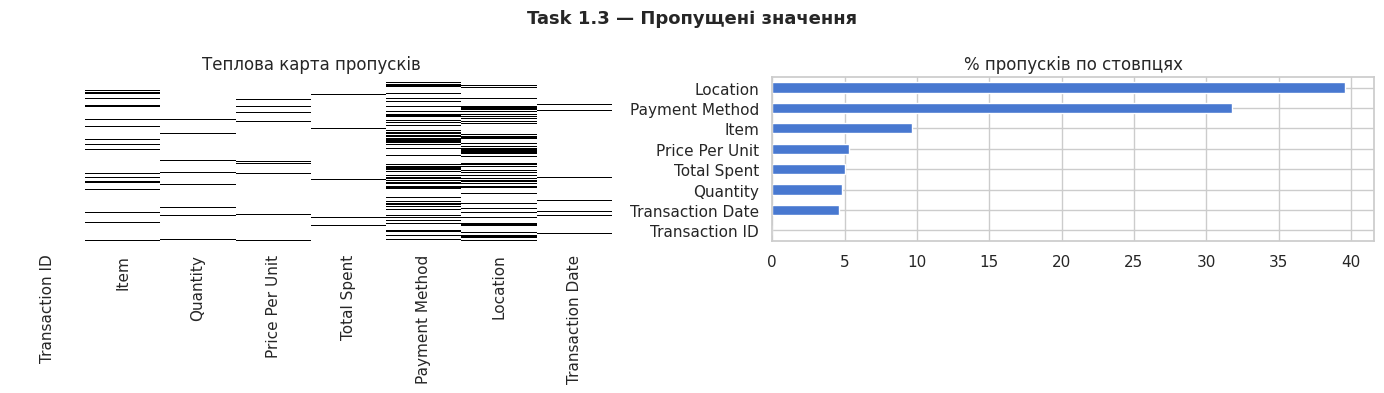

In [7]:
# Крок 4: візуалізація пропусків
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 1.3 — Пропущені значення', fontsize=13, fontweight='bold')

# Графік 1: Heatmap пропусків
# Підказка: sns.heatmap(df.isnull(), cbar=False, ...)
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='Greys',
    ax=axes[0]
)

axes[0].set_title('Теплова карта пропусків')

# Графік 2: Horizontal bar chart — % пропусків по колонках
# Підказка: .plot(kind='barh', ax=axes[1], ...)
missing_pct.sort_values().plot(
    kind='barh',
    ax=axes[1]
)


axes[1].set_title('% пропусків по стовпцях')

plt.tight_layout()
plt.show()


---
# ЧАСТИНА 2 — Очищення даних

---

## Підготовка: перейменування колонок

Перейменуйте колонки: приберіть пробіли і зробіть назви у форматі `snake_case`.

| Стара назва | Нова назва |
|-------------|------------|
| `Transaction ID` | `transaction_id` |
| `Item` | `item` |
| `Quantity` | `quantity` |
| `Price Per Unit` | `price_per_unit` |
| `Total Spent` | `total_spent` |
| `Payment Method` | `payment_method` |
| `Location` | `location` |
| `Transaction Date` | `transaction_date` |

In [8]:
# Крок 1: прибрати пробіли з назв
df.columns = df.columns.str.replace(' ', '_').str.lower()

# Крок 2: перейменувати
df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print('Нові назви колонок:', list(df.columns))

Нові назви колонок: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


## Task 2.1 — Обробка пропусків у категорійних колонках

**Стратегії:**

| Колонка | Стратегія |
|---------|----------|
| `transaction_id` | Видалити рядок |
| `item` | По ціні зі словника (якщо є price) → інакше мода |
| `payment_method` | `'Unknown'` — рекомендовано; або мода (варіант Б) |
| `location` | `'Unknown'` — рекомендовано; або мода (варіант Б) |

**Підказки:**
- `df.dropna(subset=[...])` — видалити рядки де NaN у вказаних колонках
- `df['col'].fillna('Unknown')` — заповнити рядком
- Словник і мода для item — виконуються у Task 2.2 після конвертації числових типів

In [9]:
# transaction_id: видалити рядки де NaN
before = len(df)
df = df.dropna(subset=['transaction_id'])
print(f'Видалено рядків без transaction_id: {before - len(df)}')

# payment_method:
# Варіант А (рекомендований) — заповнити 'Unknown'
df['payment_method'] = df['payment_method'].fillna('Unknown')

# Варіант Б — заповнити модою (розкоментуйте)
# mode_pay = df['payment_method'].mode()[0]
# df['payment_method'].fillna(mode_pay, inplace=True)

# location:
# Варіант А (рекомендований) — заповнити 'Unknown'
df['location'] = df['location'].fillna('Unknown')

# Варіант Б — заповнити модою (розкоментуйте)
# mode_loc = df['location'].mode()[0]
# df['location'].fillna(mode_loc, inplace=True)

# item: заповнюємо у Task 2.2 після конвертації числових типів
mode_item = df['item'].mode()[0]  # зберігаємо заздалегідь
print(f'Зберегли mode_item = "{mode_item}" для резервного заповнення')

Видалено рядків без transaction_id: 0
Зберегли mode_item = "Juice" для резервного заповнення


## Task 2.2 — Конвертація типів і заповнення item / price / quantity

**Порядок дій:**
1. Конвертувати числові типи (`errors='coerce'`)
2. Побудувати словник `ITEM_PRICE` кодом: `item → мода ціни` з даних
3. **Ситуація 1:** item = NaN, price є → знайти item зі зворотного словника
4. **Ситуація 2:** item є, price = NaN → знайти price зі словника
5. **Ситуація 3:** обидва NaN → item = мода, price = по item
6. **quantity:** якщо є price і total → `qty = total / price`; інакше медіана по товару
7. Відновити `total_spent = qty × price`, перевірити збіг

**Підказки:**
```python
# Побудова словника з даних
df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
# Зворотний словник
{round(v,2): k for k, v in ITEM_PRICE.items()}
# Медіана по групі
df.groupby('item')['quantity'].transform('median')
```

In [11]:

# Конвертація числових колонок (errors='coerce' → некоректне стає NaN)
df['quantity']         = pd.to_numeric(df['quantity'], errors='coerce')
df['price_per_unit']   = pd.to_numeric(df['price_per_unit'], errors='coerce')
df['total_spent']      = pd.to_numeric(df['total_spent'], errors='coerce')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

print('Типи після конвертації:')
print(df.dtypes)


Типи після конвертації:
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
dtype: object


In [12]:
# Крок 0: будуємо словник ITEM_PRICE з даних (item → мода ціни)
# ITEM_PRICE = df.groupby('item')['price_per_unit'].agg(lambda x: x.mode().tolist()).to_dict()
ITEM_PRICE = (
    df
    .dropna(subset=['item','price_per_unit'])  # видаляємо рядки, де продукту та ціни одначосно немає (для того, щоб мода, раптово, не видала NaN)
    .groupby('item')['price_per_unit']
    .agg(lambda x: x.mode().tolist())
    .to_dict()
)

# Підказка:
# df.dropna(subset=['item','price_per_unit'])
#   .groupby('item')['price_per_unit']
#   .agg(lambda x: x.mode()[0])
#   .to_dict()

# Зворотний словник: ціна → товар
PRICE_ITEM = {}

for key, value in ITEM_PRICE.items():
  for el in value:
    PRICE_ITEM.setdefault(el, []).append(key)

# Підказка: {round(v, 2): k for k, v in ITEM_PRICE.items()}

print(f'Словник побудовано: {len(ITEM_PRICE)} товарів\n')

print("--- ITEM_PRICE ---")
print(pd.Series(ITEM_PRICE).sort_index())

print("\n--- PRICE_ITEM ---")
print(pd.Series(PRICE_ITEM).sort_index())

Словник побудовано: 8 товарів

--- ITEM_PRICE ---
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
dtype: object

--- PRICE_ITEM ---
1.0                [Cookie]
1.5                   [Tea]
2.0                [Coffee]
3.0           [Cake, Juice]
4.0    [Sandwich, Smoothie]
5.0                 [Salad]
dtype: object


In [13]:
df.describe(include='all')
df.price_per_unit.unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

In [14]:
np.random.default_rng(42)

# Ситуація 1: item = NaN, price є → знаходимо item по ціні
mask1 = df.item.isna() & df.price_per_unit.notna()

# df.loc[mask1, 'item'] = df.loc[mask1, 'price_per_unit'].round(2).map(np.random.choice(PRICE_ITEM[df.loc[mask1, 'price_per_unit']]))
df.loc[mask1, 'item'] = (
                          df.loc[mask1, 'price_per_unit']
                          .round(2)
                          .map(lambda price: np.random.choice(PRICE_ITEM[price]) if price in PRICE_ITEM else None)
                        )

# df.head(10)

# Підказка: .round(2).map(PRICE_ITEM)
print(f'Ситуація 1 (є price → item): {mask1.sum()} рядків')

Ситуація 1 (є price → item): 915 рядків


In [15]:
# Ситуація 2: item є, price = NaN → знаходимо ціну по товару
mask2 = df.item.notna() & df.price_per_unit.isna()

df.loc[mask2, 'price_per_unit'] = (
                                    df.loc[mask2, 'item']
                                    .map(lambda it: np.random.choice(ITEM_PRICE[it]) if it in ITEM_PRICE else None)
                                  )
# Підказка: .map(ITEM_PRICE)
print(f'Ситуація 2 (є item → price): {mask2.sum()} рядків')


Ситуація 2 (є item → price): 479 рядків


In [18]:
(df.item.isna() & df.price_per_unit.isna()).sum()

np.int64(0)

In [20]:
(df.item.isna() & df.price_per_unit.isna() & df.total_spent.isna()).sum()

np.int64(0)

In [21]:
(df.item.isna() & df.price_per_unit.isna() & df.quantity.isna()).sum()

np.int64(0)

In [22]:
(df.item.isna() & df.price_per_unit.isna() & df.quantity.isna() & df.total_spent.isna()).sum()

np.int64(0)

In [23]:
# Ситуація 3: обидва NaN → item = мода, price = по item
mask3 = df.item.isna() & df.price_per_unit.isna()

mode_item = df['item'].mode()[0]   # рахуємо після заповнення ситуацій 1 і 2

df.loc[mask3, 'item'] = mode_item

df.loc[mask3, 'price_per_unit'] = ITEM_PRICE.get(mode_item)

print(f'Ситуація 3 (обидва NaN → мода "{mode_item}"): {mask3.sum()} рядків')


print(f'\nNaN у item:           {df["item"].isna().sum()}')
print(f'NaN у price_per_unit: {df["price_per_unit"].isna().sum()}')

Ситуація 3 (обидва NaN → мода "Juice"): 0 рядків

NaN у item:           0
NaN у price_per_unit: 54


In [24]:
# Заповнення quantity

# Варіант А: є price і total_spent → qty = total / price
mask_qty = (
    df['quantity'].isna() &
    df['price_per_unit'].notna() &
    df['total_spent'].notna()
)

df.loc[mask_qty, 'quantity'] = (
    df.loc[mask_qty, 'total_spent'] /
    df.loc[mask_qty, 'price_per_unit']
).round()


print(f'quantity відновлено через total/price: {mask_qty.sum()} рядків')


quantity відновлено через total/price: 456 рядків


In [25]:
# Варіант Б: решта NaN → медіана по товару
qty_median = df.groupby('item')['quantity'].transform('median')


df['quantity'] = df['quantity'].fillna(qty_median)

df['quantity'] = df['quantity'].round().astype('Int64')


print(f'quantity після медіани по товару: {df["quantity"].isna().sum()} NaN залишилось')

quantity після медіани по товару: 0 NaN залишилось


In [26]:
# Відновлення total_spent там де він NaN

mask_total = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_total, 'total_spent'] = (
    df.loc[mask_total, 'quantity'] *
    df.loc[mask_total, 'price_per_unit']
)

print(f'total_spent відновлено (був NaN): {mask_total.sum()} рядків')


# Залишкові NaN total_spent → медіана
df['total_spent'] = df['total_spent'].fillna(
    df['total_spent'].median()
)

total_spent відновлено (був NaN): 499 рядків


### Перевірка total_spent і рішення про розбіжності

Після відновлення порівняйте `total_spent` з `quantity × price_per_unit`.

Якщо є розбіжності — що з ними робити?

| Ситуація | Рішення |
|----------|---------|
| `total_spent` відновлювався з NaN | Перерахований вже правильний — залишити |
| `qty` або `price` відновлювались (мода/словник) | Перерахований надійніший — **перезаписати** |
| Всі поля були в оригіналі, але не збігаються | Помилка вводу — **перезаписати** |

У нашому проєкті — **перезаписуємо** скрізь де є розбіжність,
бо ціни зі словника надійніші за оригінал.

In [36]:

# Крок 1: порахувати очікуване значення для кожного рядка
df['_expected'] = (df.quantity * df.price_per_unit).round(2)

# Крок 2: знайти рядки де total_spent не збігається з _expected
mask_mismatch = (df['_expected'] != df['total_spent'])
n_mismatch = mask_mismatch.sum()

print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch} рядків')

df.drop(columns=['_expected'], inplace=True)
df.head(1)


Збігів:       9540 / 9540
Розбіжностей: 0 рядків


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08


In [37]:
# Крок 3: показати перші 5 розбіжностей
if n_mismatch > 0:

    print('\nПерші 5 (до виправлення):')
    print(
        df.loc[
            mask_mismatch,
            ['item', 'quantity', 'price_per_unit', 'total_spent']
        ].head()
    )

    # Перерахунок total_spent
    df.loc[mask_mismatch, 'total_spent'] = (
        df.loc[mask_mismatch, 'quantity'].astype(float) *
        df.loc[mask_mismatch, 'price_per_unit']
    ).round(2)

    print(f'\n→ total_spent перераховано для {n_mismatch} рядків')


# Крок 5: фінальна перевірка без _expected
check_total = (
    df['quantity'].astype(float) *
    df['price_per_unit']
).round(2)


still_bad = (
    df['total_spent'].round(2) != check_total
).sum()


print(f'\nФінальна перевірка: {still_bad} розбіжностей залишилось')


# Крок 6: видалити рядки без дати
before = len(df)

df = df.dropna(subset=['transaction_date'])

print(f'Видалено рядків без дати: {before - len(df)}')


df.head(1)


Фінальна перевірка: 51 розбіжностей залишилось
Видалено рядків без дати: 0


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08


## Task 2.3 — Стандартизація тексту

Приведіть `item`, `payment_method`, `location` до єдиного формату:
- Приберіть зайві пробіли (`.str.strip()`)
- Кожне слово з великої літери (`.str.title()`)

In [38]:
## Task 2.3 — Стандартизація тексту

for col in ['item', 'payment_method', 'location']:
    df[col] = (
        df[col]
        .str.strip()
        .str.title()
    )
print('Унікальні payment_method:', sorted(df['payment_method'].unique()))
print('Унікальні location:', sorted(df['location'].unique()))

Унікальні payment_method: ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']
Унікальні location: ['In-Store', 'Takeaway', 'Unknown']


## Task 2.4 — Feature Engineering

З колонки `transaction_date` витягніть нові ознаки:

| Нова колонка | Що містить | Підказка |
|-------------|------------|----------|
| `year` | Рік (число) | `.dt.year` |
| `month` | Місяць (число 1–12) | `.dt.month` |
| `month_name` | Назва місяця рядком | `.dt.strftime('%B')` |
| `weekday` | Назва дня тижня | `.dt.day_name()` |
| `is_weekend` | True якщо сб/нд | `.isin(['Saturday', 'Sunday'])` |

In [39]:

df['year']       = df['transaction_date'].dt.year
df['month']      = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%B').round()
df['weekday']    = df['transaction_date'].dt.day_name()
df['week']       = df['transaction_date'].dt.isocalendar().week.astype('Int64')
df['is_weekend'] = df["week"].isin(["Saturday", "Sunday"])

# Перевірка логічності
df = df[df['quantity'] > 0]
df = df[df['total_spent'] > 0]

print(f'✓ Фінальний датасет: {df.shape}')
print('\nПерші рядки з новими колонками:')
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'is_weekend']].head()

✓ Фінальний датасет: (9489, 14)

Перші рядки з новими колонками:


,transaction_date,year,month,month_name,weekday,is_weekend
0,2023-09-08,2023,9,September,Friday,False
1,2023-05-16,2023,5,May,Tuesday,False
2,2023-07-19,2023,7,July,Wednesday,False
3,2023-04-27,2023,4,April,Thursday,False
4,2023-06-11,2023,6,June,Sunday,False


In [40]:
# Зберегти чистий файл
df_tableau = df.copy()
df_tableau['transaction_date'] = df_tableau['transaction_date'].dt.strftime('%Y-%m-%d')
df_tableau['is_weekend'] = df_tableau['is_weekend'].map({True: 'Yes', False: 'No'})
df_tableau.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')
print(f'✓ Збережено: {FILE_OUT} — готовий для Tableau!')

✓ Збережено: https://raw.githubusercontent.com/VikiTarasova/Analysis_Cafe_Sales/refs/heads/main/data/cafe_sales_clean.csv — готовий для Tableau!


---
# ЧАСТИНА 3 — EDA

---

## Task 3.1 — Топ товари

**Що потрібно:**
1. Топ-5 товарів за `quantity` (кількість)
2. Топ-5 товарів за `total_spent` (виторг)
3. Два bar chart поруч — один для кожного топу

**Підказка:** `df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)`

In [41]:
## Task 3.1 — Топ товари

# Топ-5 за кількістю
top_qty = (
    df.groupby('item')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# Топ-5 за виторгом
top_rev = (
    df.groupby('item')['total_spent']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print('Топ-5 за кількістю:')
print(top_qty.to_string())

print('\nТоп-5 за виторгом:')
print(top_rev.round(2).to_string())

Топ-5 за кількістю:
item
Coffee      3755
Juice       3651
Cake        3648
Salad       3646
Smoothie    3575

Топ-5 за виторгом:
item
Salad       18230.0
Smoothie    14300.0
Sandwich    14140.0
Juice       10953.0
Cake        10944.0


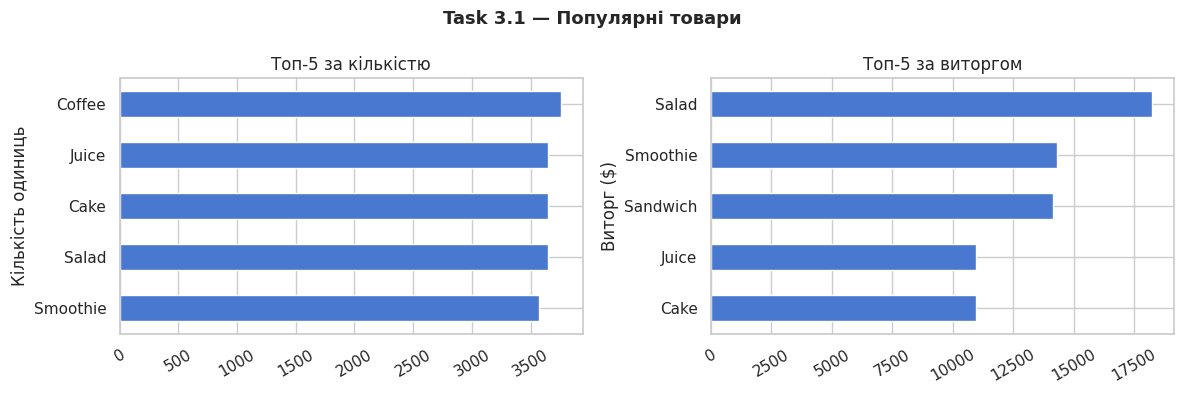

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Task 3.1 — Популярні товари', fontsize=13, fontweight='bold')

# Графік 1: топ за кількістю
top_qty.sort_values().plot(
    kind='barh',
    ax=axes[0]
)

axes[0].set_title('Топ-5 за кількістю')
axes[0].set_ylabel('Кількість одиниць')
axes[0].tick_params(axis='x', rotation=30)

# Графік 2: топ за виторгом
top_rev.sort_values().plot(
    kind='barh',
    ax=axes[1]
)

axes[1].set_title('Топ-5 за виторгом')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task31.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.1
*(Що помітили? Чи збігаються топи за кількістю та виторгом?)*

- Топи за кількістю і виторгом не збігаються повністю. Наприклад, Coffee — лідер за продажами, але не входить у топ за доходом через низьку ціну. Натомість Salad і Sandwich приносять найбільший виторг, хоча продаються рідше.  

Висновок: часті продажі ≠ високий дохід, важлива ще й ціна товару.  

## Task 3.2 — Payment Method та Location

**Що потрібно:**
1. Загальний виторг по `payment_method` — pie chart
2. Загальний виторг по `location` — bar chart

**Підказка:** `df.groupby('payment_method')['total_spent'].sum()`

In [49]:
rev_pay = (
    df.groupby('payment_method')['total_spent']
    .sum()
    .sort_values(ascending=False)
)
rev_loc = (
    df.groupby('location')['total_spent']
    .sum()
    .sort_values(ascending=False)
)

print('Виторг по оплаті:')
print(rev_pay.round(2).to_string())
print('\nВиторг по локації:')
print(rev_loc.round(2).to_string())

Виторг по оплаті:
payment_method
Unknown           26211.0
Digital Wallet    19533.5
Cash              19499.0
Credit Card       19383.5

Виторг по локації:
location
Unknown     33517.5
In-Store    25807.0
Takeaway    25302.5


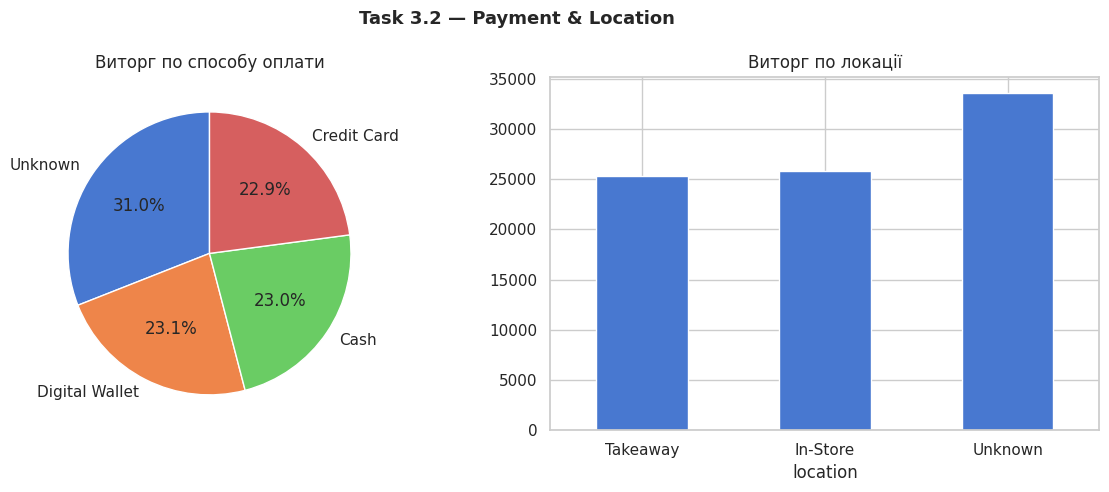

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.2 — Payment & Location', fontsize=13, fontweight='bold')


# Pie chart — payment_method
axes[0].pie(
    rev_pay,
    labels=rev_pay.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[0].set_title('Виторг по способу оплати')


# Bar chart — location
rev_loc.sort_values().plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title('Виторг по локації')
axes[1].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.savefig('part3_task32.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.2

- Який спосіб оплати домінує: Unknown (але це аномалія даних, а не реальний спосіб оплати) тому реальне лідерство у Digital Wallet, та між Cash і Credit Card приблизно однакові показники.
- In-store чи Takeaway більше: In-Store (трохи більший виторг, ніж Takeaway).

## Task 3.3 — Часові тренди

**Що потрібно:**
1. Щоденний виторг — лінійний графік
2. Щомісячний виторг — bar chart
3. Середній виторг по днях тижня — bar chart (червоний = вихідні)

**Підказки:**
- `df.groupby('transaction_date')['total_spent'].sum().reset_index()`
- `df.groupby('weekday')['total_spent'].mean().reindex(dow_order)`
- Правильний порядок: `['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']`

In [51]:
## Task 3.3 — Часові тренди

# Щоденний виторг
daily_rev = (
    df.groupby('transaction_date')['total_spent']
    .sum()
    .reset_index()
)

# Щомісячний виторг
monthly_rev = (
    df.groupby(df['transaction_date'].dt.to_period('M'))['total_spent']
    .sum()
    .reset_index()
)

# По днях тижня (середнє)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

avg_dow = (
    df.groupby(df['transaction_date'].dt.day_name())['total_spent']
    .mean()
    .reindex(dow_order)
)

print(f'Найкращий день: {avg_dow.idxmax()}')
print(f'Найгірший день: {avg_dow.idxmin()}')

Найкращий день: Tuesday
Найгірший день: Wednesday


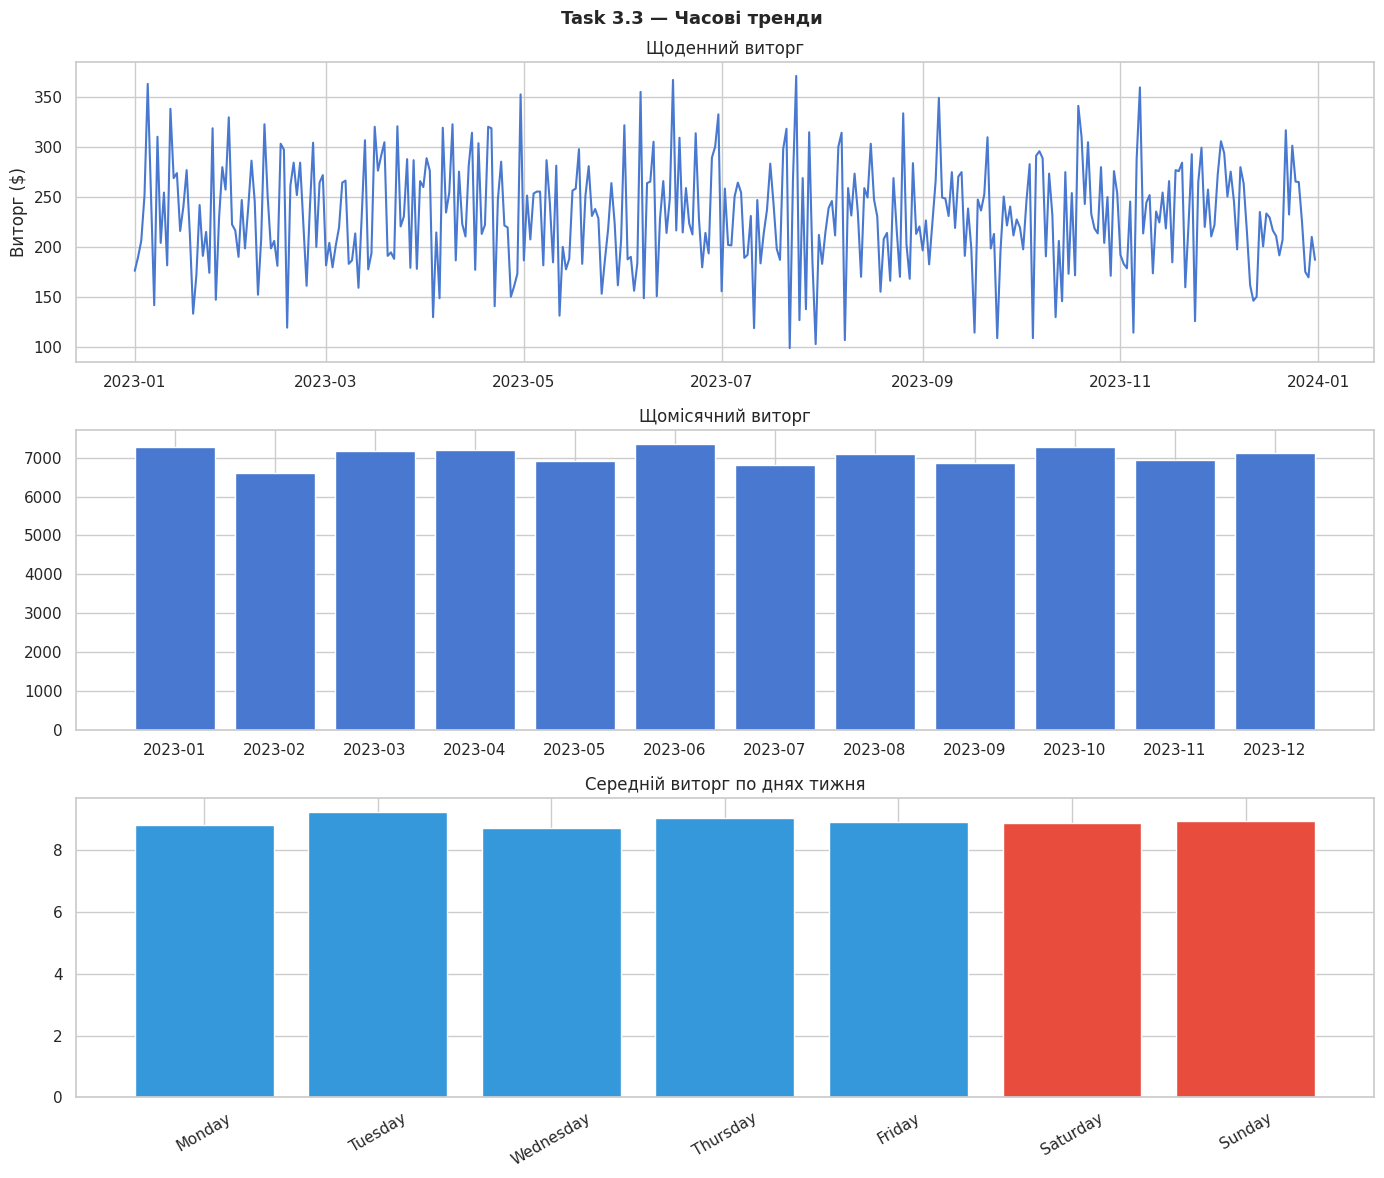

Місяць з найнижчим виторгом: 2023-02


In [52]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Task 3.3 — Часові тренди', fontsize=13, fontweight='bold')


# Графік 1: щоденний лінійний
axes[0].plot(daily_rev['transaction_date'], daily_rev['total_spent'])
axes[0].set_title('Щоденний виторг')
axes[0].set_ylabel('Виторг ($)')


# Графік 2: щомісячний бар
monthly_rev['label'] = monthly_rev['transaction_date'].astype(str)

axes[1].bar(
    monthly_rev['label'],
    monthly_rev['total_spent']
)

axes[1].set_title('Щомісячний виторг')


# Графік 3: по днях тижня
colors_dow = [
    '#E74C3C' if d in ['Saturday', 'Sunday'] else '#3498DB'
    for d in avg_dow.index
]

axes[2].bar(
    avg_dow.index,
    avg_dow.values,
    color=colors_dow
)

axes[2].set_title('Середній виторг по днях тижня')
axes[2].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.savefig('part3_task33.png', dpi=130, bbox_inches='tight')
plt.show()


# Знайти місяць з найнижчим виторгом
worst_month = monthly_rev.loc[
    monthly_rev['total_spent'].idxmin(),
    'transaction_date'
]

print(f'Місяць з найнижчим виторгом: {worst_month}')

### ✏️ Висновок до Task 3.3

- Найкращий день тижня: Вівторок
- Найгірший місяць: лютий 2023 року
- Є сезонний тренд? Явного виявлення сезонності немає, продажі стабільні і коливаються місяць до місяця.

## Task 3.4 — Виявлення викидів

**Що потрібно:**
1. Побудувати boxplot для `quantity` і `total_spent`
2. Розрахувати межі викидів методом IQR
3. Порахувати кількість викидів
4. Прийняти рішення: видалити, залишити або кепувати

**Формули IQR:**
```
IQR = Q3 - Q1
Нижня межа = Q1 - 1.5 × IQR
Верхня межа = Q3 + 1.5 × IQR
```

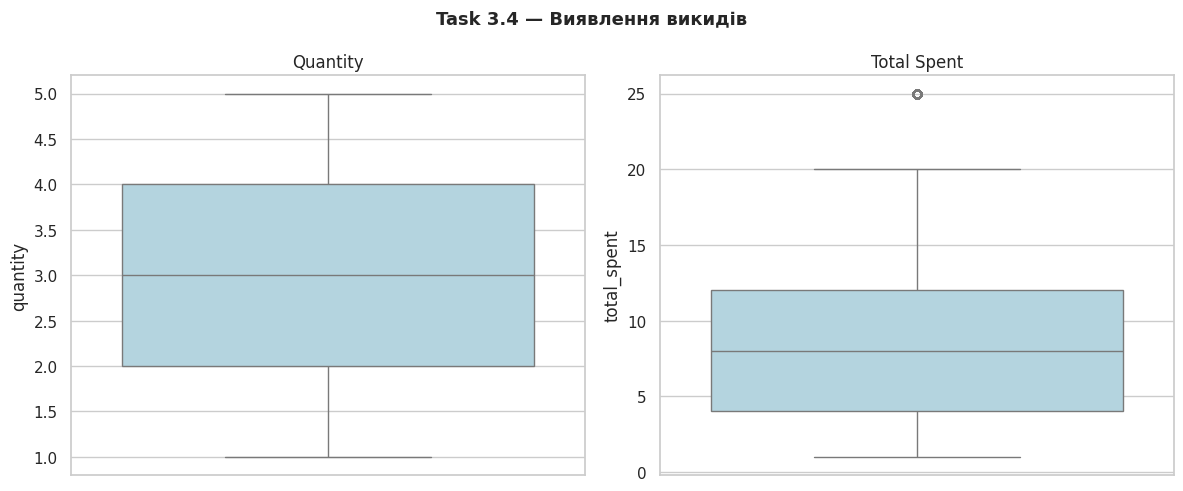

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.4 — Виявлення викидів', fontsize=13, fontweight='bold')

# Boxplot для quantity
# Підказка: sns.boxplot(y=df['quantity'].astype(float), ax=axes[0], color='lightblue', ...)
sns.boxplot(
      y=df['quantity'].astype(float),
      ax=axes[0],
      color='lightblue',
      flierprops=dict(marker='o', color='red', alpha=0.5)
    )

axes[0].set_title('Quantity')

# Boxplot для total_spent
sns.boxplot(
      y=df['total_spent'].astype(float),
      ax=axes[1],
      color='lightblue',
      flierprops=dict(marker='o', color='red', alpha=0.5)
    )

axes[1].set_title('Total Spent')

plt.tight_layout()
plt.savefig('part3_task34.png', dpi=130, bbox_inches='tight')
plt.show()


In [54]:
# Кількісний аналіз викидів методом IQR
Q1  = df.total_spent.quantile(0.25)  # 25-й перцентиль
Q3  = df.total_spent.quantile(0.75)  # 75-й перцентиль
IQR = Q3 - Q1

low  = Q1 - 1.5 * IQR  # нижня межа
high = Q3 + 1.5 * IQR  # верхня межа

n_outliers = ((df.total_spent < low) | (df.total_spent > high)).sum()  # кількість значень поза межами

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Нормальний діапазон: [{low:.2f}, {high:.2f}]')
print(f'Кількість викидів: {n_outliers}')


Q1=4.00, Q3=12.00, IQR=8.00
Нормальний діапазон: [-8.00, 24.00]
Кількість викидів: 259


### ✏️ Рішення щодо викидів
*(Напишіть своє рішення та обгрунтування)*

**Рішення:** залишити / видалити / <u>кепувати</u>  
(потрібне підкресліть)

---

**Обгрунтування:**
Кількість викидів (259) є значною, але повне видалення даних може призвести до втрати важливої інформації про поведінку клієнтів. Оскільки викиди знаходяться в межах бізнес-даних (покупки, виторг), а не є помилками, краще обмежити їх значення межами нормального діапазону −8,24. Це дозволяє зберегти структуру даних і при цьому зменшити вплив крайніх значень на середні показники та моделі.

## Task 3.5 — Кореляційний аналіз

**Що потрібно:**
1. Порахувати кореляційну матрицю для `quantity`, `price_per_unit`, `total_spent`
2. Побудувати heatmap
3. Інтерпретувати результати

**Підказка:** `df[cols].astype(float).corr()`

Кореляційна матриця:
                quantity  price_per_unit  total_spent
quantity           1.000           0.008        0.704
price_per_unit     0.008           1.000        0.647
total_spent        0.704           0.647        1.000


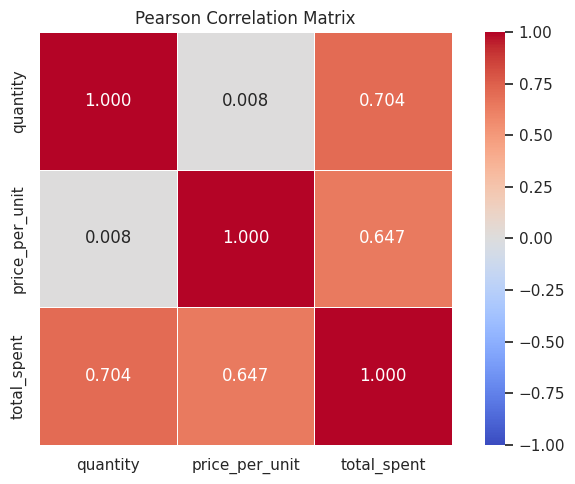

In [56]:
corr_cols   = ['quantity', 'price_per_unit', 'total_spent']
corr_matrix = df[corr_cols].astype(float).corr()

print('Кореляційна матриця:')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

# Heatmap кореляцій
# Підказка: sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ...)
sns.heatmap(
        corr_matrix,
        annot=True, fmt='.3f',
        cmap='coolwarm',
        vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax,
        annot_kws={'size': 12}
    )

ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('part3_task35.png', dpi=130, bbox_inches='tight')
plt.show()


### ✏️ Інтерпретація кореляцій

| Пара | Значення | Сила | Пояснення |
|------|----------|------|-----------|
| total_spent ↔ quantity | ___ | ___ | ___ |
| total_spent ↔ price_per_unit | ___ | ___ | ___ |
| quantity ↔ price_per_unit | ___ | ___ | ___ |

---
# ЧАСТИНА 4 — Висновки та рекомендації

---

In [57]:
# Збір ключових метрик

top_item_rev = df.groupby('item')['total_spent'].sum().idxmax() #   (найприбутковіший товар)
top_item_qty = df.groupby('item')['quantity'].sum().idxmax() #  (найпопулярніший за кількістю)

top_pay = df.groupby('payment_method')['total_spent'].sum().idxmax() # (домінуючий спосіб оплати)
top_loc = df.groupby('location')['total_spent'].sum().idxmax() #  (топ локація)

total_revenue = df['total_spent'].sum()
avg_check = df['total_spent'].mean()


print('=' * 55)
print('  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ')
print('=' * 55)


print(f'Найприбутковіший товар: {top_item_rev}')
print(f'Найпопулярніший товар: {top_item_qty}')
print(f'Домінуючий спосіб оплати: {top_pay}')
print(f'Топ локація: {top_loc}')
print(f'Загальний виторг: {total_revenue:.2f}')
print(f'Середній чек: {avg_check:.2f}')

  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ
Найприбутковіший товар: Salad
Найпопулярніший товар: Coffee
Домінуючий спосіб оплати: Unknown
Топ локація: Unknown
Загальний виторг: 84627.00
Середній чек: 8.92


## ✅ Фінальний чеклист

Поставте ✓ навпроти кожного виконаного пункту:

**Частина 1**
- [✓] Завантажено і оглянуто датасет
- [✓] Знайдено і видалено дублікати
- [✓] Порахована і візуалізована кількість пропусків

**Частина 2**
- [✓] Перейменовано колонки
- [✓] Замінено ERROR/UNKNOWN на NaN
- [✓] Заповнено пропуски payment_method і location
- [✓] Конвертовано типи даних
- [✓] Побудовано словник ITEM_PRICE з даних
- [✓] Оброблено три ситуації item/price
- [✓] Відновлено quantity (через total/price або медіана по товару)
- [✓] Відновлено total_spent, перевірено збіг і перезаписано розбіжності
- [✓] Стандартизовано текст
- [✓] Додано часові ознаки
- [✓] Збережено FILE_OUT

**Частина 3**
- [✓] Task 3.1: топ товари — два бар-чарти
- [✓] Task 3.2: оплата і локація — pie + bar
- [✓] Task 3.3: часові тренди — 3 графіки
- [✓] Task 3.4: boxplot + IQR аналіз
- [✓] Task 3.5: кореляційна матриця + heatmap

**Частина 4**
- [✓] Підсумковий звіт з конкретними числами
- [✓] Мінімум 1 бізнес-рекомендація

---
**🎉 Вітаємо з завершенням проєкту!**